
✅ Analysis complete with OVERALL row!
Text results saved to: mcnemar_results_(Unseen).txt
Table image saved to: mcnemar_summary_table (Unseen).png


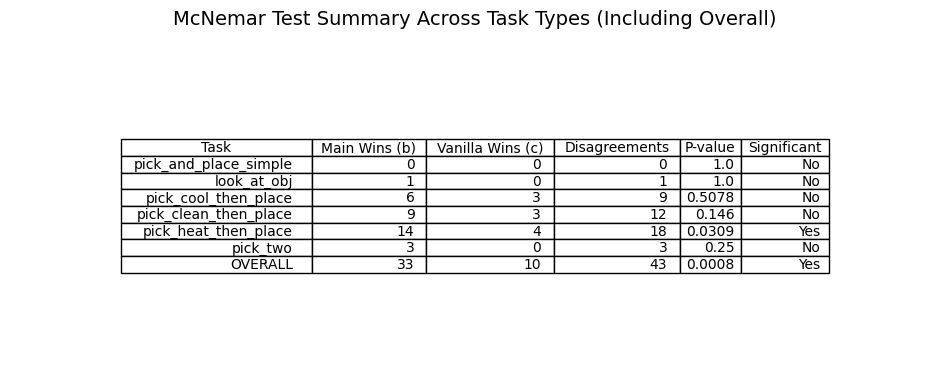

In [16]:
# pip install pandas statsmodels matplotlib

import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
task_types = [
    "pick_and_place_simple",
    "look_at_obj",
    "pick_cool_then_place",
    "pick_clean_then_place",
    "pick_heat_then_place",
    "pick_two"
]

output_txt = "mcnemar_results_(Unseen).txt"
output_img = "mcnemar_summary_table (Unseen).png"


# ---------- Helper ----------
def load_clean_csv(path):
    df = pd.read_csv(path, sep="\t", engine="python")
    if len(df.columns) == 1:
        df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


# ---------- Storage ----------
results = []

# Overall accumulators
total_b = 0
total_c = 0
total_both_success = 0
total_both_fail = 0

with open(output_txt, "w") as f:

    f.write("McNemar Test Results\n")
    f.write("=" * 50 + "\n\n")

    # ---------- Loop over tasks ----------
    for task in task_types:
        try: 
            main_path = f"mcnemers/success_ratio_unseen_{task}__Main.csv"
            vanilla_path = f"mcnemers/success_ratio_unseen_{task}__Vanilla.csv"
# CSV_LOG_FILE = f"Unseen_{PREFIX}/success_ratio_unseen_{PREFIX}_{Approach}.csv"

            main_df = load_clean_csv(main_path)
            vanilla_df = load_clean_csv(vanilla_path)

            assert len(main_df) == len(vanilla_df)

            main_s = main_df["success"]
            vanilla_s = vanilla_df["success"]

            # Compute values
            both_success = ((main_s == 1) & (vanilla_s == 1)).sum()
            both_fail = ((main_s == 0) & (vanilla_s == 0)).sum()
            b = ((main_s == 1) & (vanilla_s == 0)).sum()
            c = ((main_s == 0) & (vanilla_s == 1)).sum()

            # Accumulate totals
            total_b += b
            total_c += c
            total_both_success += both_success
            total_both_fail += both_fail

            total_disagreements = b + c

            table = [[both_success, b],
                     [c, both_fail]]

            # Select test
            if total_disagreements < 25:
                result = mcnemar(table, exact=True)
                test_type = "Exact"
            else:
                result = mcnemar(table, exact=False, correction=True)
                test_type = "Chi-square"

            p_value = result.pvalue
            significance = "Yes" if p_value <= 0.05 else "No"

            results.append([
                task, b, c, total_disagreements,
                round(p_value, 4), significance
            ])

            # Write to TXT
            f.write(f"Task: {task}\n")
            f.write(f"b (Main wins): {b}\n")
            f.write(f"c (Vanilla wins): {c}\n")
            f.write(f"Disagreements: {total_disagreements}\n")
            f.write(f"P-value: {p_value:.6f}\n")
            f.write(f"Significant: {significance}\n")
            f.write("-" * 40 + "\n\n")

        except Exception as e:
            print(f"Error processing {task}: {e}")


    # ---------- OVERALL McNemar ----------
    overall_table = [[total_both_success, total_b],
                     [total_c, total_both_fail]]

    if (total_b + total_c) < 25:
        overall_result = mcnemar(overall_table, exact=True)
    else:
        overall_result = mcnemar(overall_table, exact=False, correction=True)

    overall_p = overall_result.pvalue
    overall_sig = "Yes" if overall_p <= 0.05 else "No"

    # Add to results table
    results.append([
        "OVERALL",
        total_b,
        total_c,
        total_b + total_c,
        round(overall_p, 4),
        overall_sig
    ])

    # Write to TXT
    f.write("OVERALL RESULTS\n")
    f.write(f"Total b (Main wins): {total_b}\n")
    f.write(f"Total c (Vanilla wins): {total_c}\n")
    f.write(f"Total disagreements: {total_b + total_c}\n")
    f.write(f"P-value: {overall_p:.6f}\n")
    f.write(f"Significant: {overall_sig}\n")


# ---------- Create Table Image ----------
df_results = pd.DataFrame(
    results,
    columns=["Task", "Main Wins (b)", "Vanilla Wins (c)", "Disagreements", "P-value", "Significant"]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df_results.columns))))

plt.title("McNemar Test Summary Across Task Types (Including Overall)", fontsize=14, pad=20)

plt.savefig(output_img, bbox_inches='tight', dpi=300)

print("\n✅ Analysis complete with OVERALL row!")
print(f"Text results saved to: {output_txt}")
print(f"Table image saved to: {output_img}")


✅ Analysis complete with OVERALL row!
Text results saved to: mcnemar_results_(Seen).txt
Table image saved to: mcnemar_summary_table (Seen).png


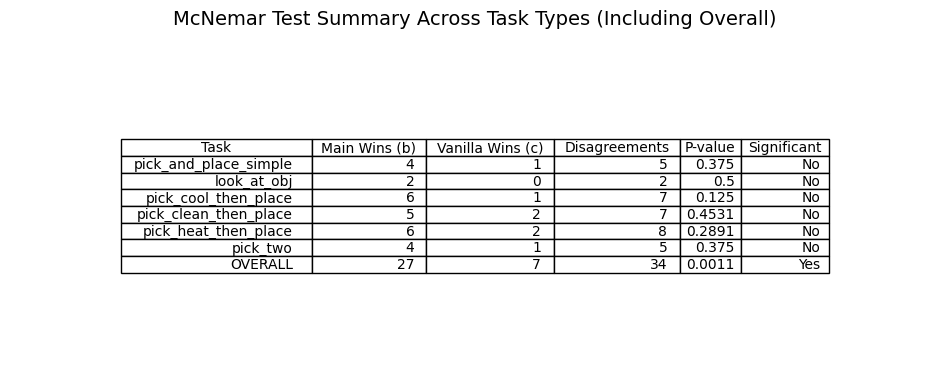

In [20]:
# pip install pandas statsmodels matplotlib

import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
task_types = [
    "pick_and_place_simple",
    "look_at_obj",
    "pick_cool_then_place",
    "pick_clean_then_place",
    "pick_heat_then_place",
    "pick_two"
]

output_txt = "mcnemar_results_(Seen).txt"
output_img = "mcnemar_summary_table (Seen).png"


# ---------- Helper ----------
def load_clean_csv(path):
    df = pd.read_csv(path, sep="\t", engine="python")
    if len(df.columns) == 1:
        df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df


# ---------- Storage ----------
results = []

# Overall accumulators
total_b = 0
total_c = 0
total_both_success = 0
total_both_fail = 0

with open(output_txt, "w") as f:

    f.write("McNemar Test Results\n")
    f.write("=" * 50 + "\n\n")

    # ---------- Loop over tasks ----------
    for task in task_types:
        try: 
            main_path = f"success_ratio_{task}_Main.csv"
            vanilla_path = f"success_ratio_{task}_Vanilla.csv"
# CSV_LOG_FILE = f"Unseen_{PREFIX}/success_ratio_unseen_{PREFIX}_{Approach}.csv"

            main_df = load_clean_csv(main_path)
            vanilla_df = load_clean_csv(vanilla_path)

            assert len(main_df) == len(vanilla_df)

            main_s = main_df["success"]
            vanilla_s = vanilla_df["success"]

            # Compute values
            both_success = ((main_s == 1) & (vanilla_s == 1)).sum()
            both_fail = ((main_s == 0) & (vanilla_s == 0)).sum()
            b = ((main_s == 1) & (vanilla_s == 0)).sum()
            c = ((main_s == 0) & (vanilla_s == 1)).sum()

            # Accumulate totals
            total_b += b
            total_c += c
            total_both_success += both_success
            total_both_fail += both_fail

            total_disagreements = b + c

            table = [[both_success, b],
                     [c, both_fail]]

            # Select test
            if total_disagreements < 25:
                result = mcnemar(table, exact=True)
                test_type = "Exact"
            else:
                result = mcnemar(table, exact=False, correction=True)
                test_type = "Chi-square"

            p_value = result.pvalue
            significance = "Yes" if p_value <= 0.05 else "No"

            results.append([
                task, b, c, total_disagreements,
                round(p_value, 4), significance
            ])

            # Write to TXT
            f.write(f"Task: {task}\n")
            f.write(f"b (Main wins): {b}\n")
            f.write(f"c (Vanilla wins): {c}\n")
            f.write(f"Disagreements: {total_disagreements}\n")
            f.write(f"P-value: {p_value:.6f}\n")
            f.write(f"Significant: {significance}\n")
            f.write("-" * 40 + "\n\n")

        except Exception as e:
            print(f"Error processing {task}: {e}")


    # ---------- OVERALL McNemar ----------
    overall_table = [[total_both_success, total_b],
                     [total_c, total_both_fail]]

    if (total_b + total_c) < 25:
        overall_result = mcnemar(overall_table, exact=True)
    else:
        overall_result = mcnemar(overall_table, exact=False, correction=True)

    overall_p = overall_result.pvalue
    overall_sig = "Yes" if overall_p <= 0.05 else "No"

    # Add to results table
    results.append([
        "OVERALL",
        total_b,
        total_c,
        total_b + total_c,
        round(overall_p, 4),
        overall_sig
    ])

    # Write to TXT
    f.write("OVERALL RESULTS\n")
    f.write(f"Total b (Main wins): {total_b}\n")
    f.write(f"Total c (Vanilla wins): {total_c}\n")
    f.write(f"Total disagreements: {total_b + total_c}\n")
    f.write(f"P-value: {overall_p:.6f}\n")
    f.write(f"Significant: {overall_sig}\n")


# ---------- Create Table Image ----------
df_results = pd.DataFrame(
    results,
    columns=["Task", "Main Wins (b)", "Vanilla Wins (c)", "Disagreements", "P-value", "Significant"]
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df_results.columns))))

plt.title("McNemar Test Summary Across Task Types (Including Overall)", fontsize=14, pad=20)

plt.savefig(output_img, bbox_inches='tight', dpi=300)

print("\n✅ Analysis complete with OVERALL row!")
print(f"Text results saved to: {output_txt}")
print(f"Table image saved to: {output_img}")

In [22]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

task_types = [
    "pick_and_place_simple",
    "look_at_obj",
    "pick_cool_then_place",
    "pick_clean_then_place",
    "pick_heat_then_place",
    "pick_two"
]

def load_clean_csv(path):
    df = pd.read_csv(path, sep="\t", engine="python")
    if len(df.columns) == 1:
        df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df

results = []

for task in task_types:
    try:
        # Seen
        main_seen = load_clean_csv(f"success_ratio_{task}_Main.csv")
        van_seen = load_clean_csv(f"success_ratio_{task}_Vanilla.csv")

        # Unseen
        main_unseen = load_clean_csv(f"mcnemers/success_ratio_unseen_{task}__Main.csv")
        van_unseen = load_clean_csv(f"mcnemers/success_ratio_unseen_{task}__Vanilla.csv")

        # Combine
        main_s = pd.concat([main_seen["success"], main_unseen["success"]])
        van_s = pd.concat([van_seen["success"], van_unseen["success"]])

        # Compute counts
        both_success = ((main_s == 1) & (van_s == 1)).sum()
        both_fail = ((main_s == 0) & (van_s == 0)).sum()
        b = ((main_s == 1) & (van_s == 0)).sum()
        c = ((main_s == 0) & (van_s == 1)).sum()

        disagreements = b + c

        table = [[both_success, b],
                 [c, both_fail]]

        if disagreements < 25:
            result = mcnemar(table, exact=True)
        else:
            result = mcnemar(table, exact=False, correction=True)

        p_value = result.pvalue
        significance = "Yes" if p_value <= 0.05 else "No"

        results.append([
            task, b, c, disagreements,
            round(p_value, 4), significance
        ])

    except Exception as e:
        print(f"Error: {task} -> {e}")

# Convert to DataFrame
df_final = pd.DataFrame(
    results,
    columns=["Task", "Main Wins (b)", "Vanilla Wins (c)", "Disagreements", "P-value", "Significant"]
)

# print(df_final)
# ---------- OUTPUT FILES ----------
output_txt_combined = "mcnemar_results_(Combined).txt"
output_img_combined = "mcnemar_summary_table (Combined).png"

# ---------- WRITE TXT ----------
with open(output_txt_combined, "w") as f:

    f.write("McNemar Test Results (Combined Seen + Unseen)\n")
    f.write("=" * 50 + "\n\n")

    total_b = 0
    total_c = 0
    total_disagreements = 0

    for row in results:
        task, b, c, dis, p_val, sig = row

        total_b += b
        total_c += c
        total_disagreements += dis

        f.write(f"Task: {task}\n")
        f.write(f"b (Main wins): {b}\n")
        f.write(f"c (Vanilla wins): {c}\n")
        f.write(f"Disagreements: {dis}\n")
        f.write(f"P-value: {p_val:.6f}\n")
        f.write(f"Significant: {sig}\n")
        f.write("-" * 40 + "\n\n")

    f.write("OVERALL RESULTS\n")
    f.write(f"Total b (Main wins): {total_b}\n")
    f.write(f"Total c (Vanilla wins): {total_c}\n")
    f.write(f"Total disagreements: {total_disagreements}\n")

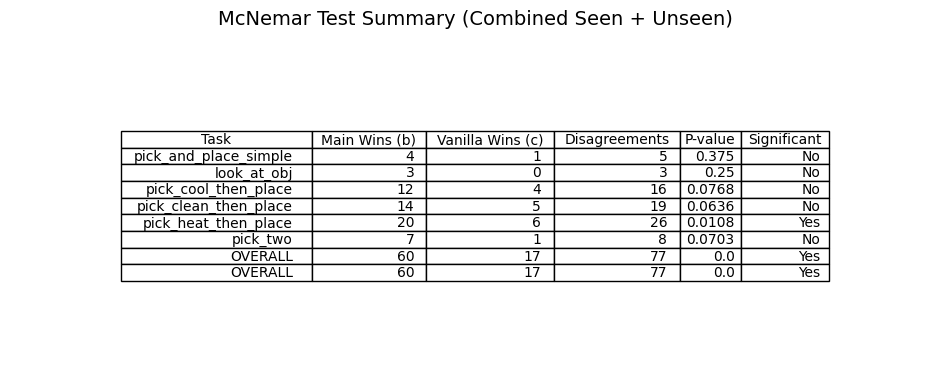

In [25]:
# ---------- OVERALL McNemar (Combined) ----------
total_b = 0
total_c = 0
total_both_success = 0
total_both_fail = 0

for task in task_types:
    try:
        # Seen
        main_seen = load_clean_csv(f"success_ratio_{task}_Main.csv")
        van_seen = load_clean_csv(f"success_ratio_{task}_Vanilla.csv")

        # Unseen
        main_unseen = load_clean_csv(f"mcnemers/success_ratio_unseen_{task}__Main.csv")
        van_unseen = load_clean_csv(f"mcnemers/success_ratio_unseen_{task}__Vanilla.csv")

        # Combine
        main_s = pd.concat([main_seen["success"], main_unseen["success"]])
        van_s = pd.concat([van_seen["success"], van_unseen["success"]])

        both_success = ((main_s == 1) & (van_s == 1)).sum()
        both_fail = ((main_s == 0) & (van_s == 0)).sum()
        b = ((main_s == 1) & (van_s == 0)).sum()
        c = ((main_s == 0) & (van_s == 1)).sum()

        total_b += b
        total_c += c
        total_both_success += both_success
        total_both_fail += both_fail

    except Exception as e:
        print(f"Error in overall calc for {task}: {e}")


overall_table = [[total_both_success, total_b],
                 [total_c, total_both_fail]]

if (total_b + total_c) < 25:
    overall_result = mcnemar(overall_table, exact=True)
else:
    overall_result = mcnemar(overall_table, exact=False, correction=True)

overall_p = overall_result.pvalue
overall_sig = "Yes" if overall_p <= 0.05 else "No"

# ✅ Append OVERALL row (same as your original format)
results.append([
    "OVERALL",
    total_b,
    total_c,
    total_b + total_c,
    round(overall_p, 4),
    overall_sig
])
# ---------- CREATE DATAFRAME ----------
df_combined = pd.DataFrame(
    results,
    columns=["Task", "Main Wins (b)", "Vanilla Wins (c)", "Disagreements", "P-value", "Significant"]
)

# ---------- PLOT TABLE ----------
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

table = ax.table(
    cellText=df_combined.values,
    colLabels=df_combined.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(df_combined.columns))))

plt.title("McNemar Test Summary (Combined Seen + Unseen)", fontsize=14, pad=20)

plt.savefig(output_img_combined, bbox_inches='tight', dpi=300)